<a href="https://colab.research.google.com/github/nashsparrow/pytorch/blob/main/1.pytorch_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
#converts MNIST Image files into Tensor of 4-Dimensions (#of iamges, Height, width, color channel
transform = transforms.ToTensor()


In [ ]:
#train data
train_data = datasets.MNIST(root='cnn_data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.72MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.92MB/s]


In [ ]:
#Test data
test_data = datasets.MNIST(root='cnn_data', train=False, download=True, transform=transform)

In [ ]:
#Loader for data
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [ ]:
#Define CNN Model
#Describe CNN layer - 2
conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1) #This out should next ones in
conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1)

In [ ]:
#Take 1 MIST image
for i, (X_Train, y_train) in enumerate(train_data):
  break

In [ ]:
X_Train.shape

torch.Size([1, 28, 28])

In [ ]:
x = X_Train.view(1,1,28,28)

In [ ]:
x = F.relu(conv1(x)) #Rectified Linear unit for activation function

In [ ]:
x.shape
#1 image, 6 filters we asked for, image size 26, 26

torch.Size([1, 6, 26, 26])

In [ ]:
#pooling layer
x = F.max_pool2d(x, 2, 2)

In [ ]:
x.shape

torch.Size([1, 6, 13, 13])

In [ ]:
#2nd convo
x = F.relu(conv2(x))

In [ ]:
x.shape

torch.Size([1, 16, 11, 11])

In [ ]:
x = F.max_pool2d(x, 2, 2)
x.shape

torch.Size([1, 16, 5, 5])

In [ ]:
#Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1)
    self.fc1 = nn.Linear(in_features=16*5*5, out_features=120) #output of the convolution layers 16*5*5, 120 arbitarary
    self.fc2 = nn.Linear(in_features=120, out_features=84)
    self.fc3 = nn.Linear(in_features=84, out_features=10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X, 2, 2)
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X, 2, 2)
    X = X.view(-1, 16*5*5) #-1 so the batch sie can be varied
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim=1)


In [ ]:
#Instance of the model

torch.manual_seed(41)
model = ConvolutionalNetwork();
model


ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
# Loss Function optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
from numpy.matrixlib import test
import time
start_time = time.time()

#create needed variables to track errors and others
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

#for loop for epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0
  #train
  for b, (X_train, y_train) in enumerate(train_loader): #For each batch
    b+=1
    #apply model
    y_pred = model(X_train) #get predicted values from training set, not flatten its 2d
    loss = criterion(y_pred, y_train) #calculate loss

    predicted = torch.max(y_pred.data, 1)[1] #Add up number of correct predictions. indexed of the furst point
    batch_correct = (predicted == y_train).sum() #how many are predicted
    trn_corr += batch_correct

    #update paraameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #print results
    if b%600 == 0:
      print(f'epoch: {i} batch: {b} loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)

  #test
  with torch.no_grad(): #no gradient
    for b, (X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1]
      tst_corr += (predicted == y_test).sum()

  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)

current_time = time.time()
print(f'Training time {(current_time - start_time)/60}')
#time measure

epoch: 0 batch: 600 loss: 0.011132054962217808
epoch: 0 batch: 1200 loss: 0.11040953546762466
epoch: 0 batch: 1800 loss: 0.6892396211624146
epoch: 0 batch: 2400 loss: 0.5411641001701355
epoch: 0 batch: 3000 loss: 0.012907926924526691
epoch: 0 batch: 3600 loss: 0.6677582263946533
epoch: 0 batch: 4200 loss: 0.009820559993386269
epoch: 0 batch: 4800 loss: 0.015080587938427925
epoch: 0 batch: 5400 loss: 0.5774227380752563
epoch: 0 batch: 6000 loss: 0.0016861114418134093
epoch: 1 batch: 600 loss: 0.013501604087650776
epoch: 1 batch: 1200 loss: 0.018279898911714554
epoch: 1 batch: 1800 loss: 0.003259468823671341
epoch: 1 batch: 2400 loss: 0.05042523890733719
epoch: 1 batch: 3000 loss: 0.09012060612440109
epoch: 1 batch: 3600 loss: 0.08855246007442474
epoch: 1 batch: 4200 loss: 0.01189345307648182
epoch: 1 batch: 4800 loss: 4.945280306856148e-05
epoch: 1 batch: 5400 loss: 0.00010991059389198199
epoch: 1 batch: 6000 loss: 0.5780960321426392
epoch: 2 batch: 600 loss: 0.15739865601062775
epoch: 

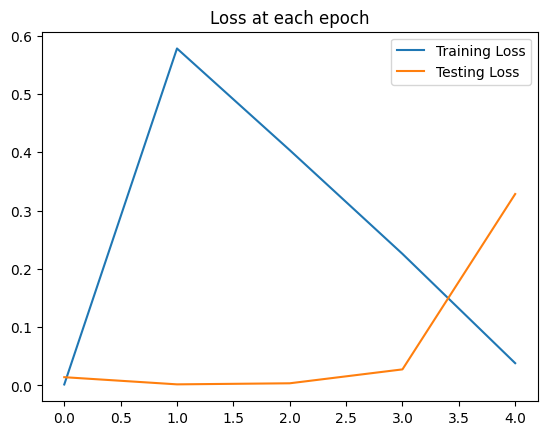

In [ ]:
#graph loss at each epoch
train_losses = [t.item() for t in train_losses]
test_losses = [t.item() for t in test_losses]
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Testing Loss')
plt.title('Loss at each epoch')
plt.legend()

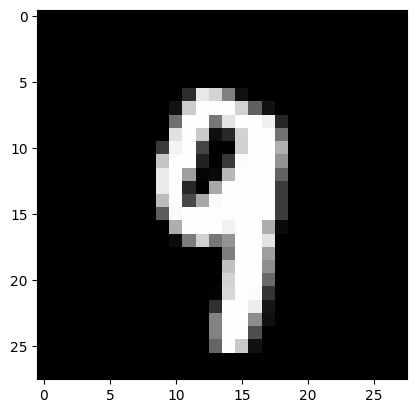

In [ ]:
plt.imshow(test_data[414][0].reshape(28,28), cmap='gray')

In [ ]:
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[414][0].view(1,1,28,28))

new_prediction

tensor([[-1.5496e+01, -1.0779e+01, -1.6033e+01, -8.0603e+00, -5.8031e+00,
         -7.4493e+00, -3.0305e+01, -6.1016e+00, -7.0413e+00, -7.0763e-03]])

In [ ]:
new_prediction.argmax()


tensor(9)